

### Compute FID for CIFAR10


(a) Preparation

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')


# change directory
%cd /content/drive/MyDrive/R3GAN-main

# install package for image generation
!pip install ninja
!pip install pytorch_fid




(b) extract cifar validation image set

In [ ]:
import os
import numpy as np
import PIL.Image
# code from https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_dict=unpickle('cifar10_validation_data/test_batch')

# make a directory
dir_images = "cifar10_validation_images"
os.makedirs(dir_images, exist_ok=True)

for idx in range(len(data_dict[b'labels'])):
  label = str(data_dict[b'labels'][idx]).zfill(2)
  img_current = data_dict[b'data'][idx,:]
  red_channel = img_current[0:1024].reshape(32,32,1)
  green_channel = img_current[1024:1024*2].reshape(32,32,1)
  blue_channel = img_current[1024*2::].reshape(32,32,1)

  img_current = np.concatenate((red_channel,green_channel,blue_channel), axis=2)
  path = os.path.join(dir_images, label+'_'+ str(idx).zfill(4)+ '.png')
  PIL.Image.fromarray(img_current, 'RGB').save(path)



/tmp/ipython-input-3117800247.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img_current, 'RGB').save(path)


(c) define a function for generating new fake images

In [ ]:
import os
import re
from typing import List, Optional, Union

import numpy as np
import PIL.Image
import torch

import legacy


def generate_images_batch(batchsize, seed, label_idx):
    # print('Loading networks from "%s"...' % network_pkl)
    device = torch.device('cuda')

    num_images = 0
    with open('network-snapshot-final.pkl', 'rb') as f:
      #my_list = pickle.load(f)
      G = legacy.load_network_pkl(f)['G_ema'].to(device) # type: ignore
      # Labels.
      label = torch.zeros([batchsize, G.c_dim], device=device)
      label[:, label_idx] = 1


      #z = torch.from_numpy(np.random.RandomState(seed).randn(batchsize, G.z_dim)).to(device)
      torch.manual_seed(seed)
      #z = torch.from_numpy(np.random.RandomState(seed).randn(batchsize, G.z_dim)).to(device)
      z = torch.randn(batchsize,G.z_dim).to(device)
      img = G(z, label)
      img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)

      return img



(d) call the function to generate a set of fake images with a particular label.

torch.Size([100, 32, 32, 3])


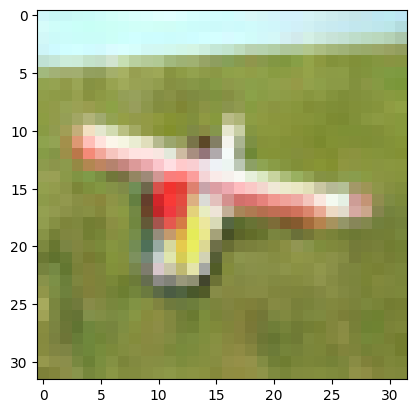

In [ ]:

img=generate_images_batch(batchsize=100, label_idx= 1, seed = 10)
print(img.shape)
import matplotlib.pyplot as plt
plt.imshow(img[0].cpu().numpy())


(e) create a new image folder

In [ ]:
image_folder = 'new_images'
os.makedirs(image_folder, exist_ok=True)

(f) Generate 1000 images per class and save the images in the image folder. In totall 10k images should be generated.

In [ ]:

for label_idx in range(0, 10,1):
  seeds = range(0,5,1)
  count_images = 0
  for seed in seeds:
    img = generate_images_batch(batchsize=200, label_idx= label_idx, seed = seed)
    for idx in range(len(img)):
      PIL.Image.fromarray(img[idx].cpu().numpy(), 'RGB').save(os.path.join(image_folder, str(label_idx).zfill(2) + '_'+str(count_images).zfill(3)+'.png'))
      count_images = count_images+1

/tmp/ipython-input-292334888.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[idx].cpu().numpy(), 'RGB').save(os.path.join(image_folder, str(label_idx).zfill(2) + '_'+str(count_images).zfill(3)+'.png'))


(f) Compute FID score

In [ ]:
refdir = '/content/drive/MyDrive/R3GAN-main/cifar10_validation_images/'
targetdir = '/content/drive/MyDrive/R3GAN-main/new_images'
!python -m pytorch_fid /content/drive/MyDrive/R3GAN-main/cifar10_validation_images /content/drive/MyDrive/R3GAN-main/new_images

100% 199/199 [00:42<00:00,  4.65it/s]
100% 200/200 [02:05<00:00,  1.59it/s]
FID:  102.00592463924659


(g) Compute conditional probability for IS score

In [ ]:
# calculate inception score with Keras
from math import floor
from numpy import ones
from numpy import expand_dims
from numpy import log
from numpy import mean
from numpy import std
from numpy import exp
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input

import glob

import cv2



files=glob.glob('/content/drive/MyDrive/R3GAN-main/new_images/*.*')

batchsize = 100
images = ones((batchsize, 299, 299, 3))

idx = 0
p_yx = ones((10000, 1000))

model = InceptionV3()

num_batches = 0
for file in files:

  tmp = cv2.imread(file)
  images[idx,:,:,:] = cv2.resize(tmp, (299, 299), interpolation=cv2.INTER_CUBIC)
  idx += 1

  if idx == batchsize:
    # convert from uint8 to float32
    processed = images.astype('float32')
    # pre-process raw images for inception v3 model
    processed = preprocess_input(processed)
    # predict class probabilities for images
    yhat = model.predict(processed)

    p_yx[num_batches*batchsize:(num_batches+1)*batchsize] = yhat
    idx = 0
    num_batches +=1
    print(num_batches)






4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
1
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step 
2
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 
3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step 
4
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
6
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
7
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 
8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
9
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 
10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
11
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 
12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
13
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
14
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 
16
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step 
17
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step 
18
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 
19
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 
21
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
22
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
23
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
24
4/4

'd'

(h) compute IS score

In [ ]:
eps=1E-16

p_y = expand_dims(p_yx.mean(axis=0), 0)
kl_d = p_yx * (log(p_yx + eps) - log(p_y + eps))
sum_kl_d = kl_d.sum(axis=1)
avg_kl_d = mean(sum_kl_d)
is_score = exp(avg_kl_d)

print(is_score)

4.190159140887236
